# Credit Card Approval Dataset

## 1. Import Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## Load/read the datasets

In [2]:
application_df = pd.read_csv('application_record.csv')
credit_df = pd.read_csv('credit_record.csv')

In [3]:
print(application_df.head())
print(credit_df.head())

        ID CODE_GENDER FLAG_OWN_CAR FLAG_OWN_REALTY  CNT_CHILDREN  \
0  5008804           M            Y               Y             0   
1  5008805           M            Y               Y             0   
2  5008806           M            Y               Y             0   
3  5008808           F            N               Y             0   
4  5008809           F            N               Y             0   

   AMT_INCOME_TOTAL      NAME_INCOME_TYPE            NAME_EDUCATION_TYPE  \
0          427500.0               Working               Higher education   
1          427500.0               Working               Higher education   
2          112500.0               Working  Secondary / secondary special   
3          270000.0  Commercial associate  Secondary / secondary special   
4          270000.0  Commercial associate  Secondary / secondary special   

     NAME_FAMILY_STATUS  NAME_HOUSING_TYPE  DAYS_BIRTH  DAYS_EMPLOYED  \
0        Civil marriage   Rented apartment      -12005 

In [4]:
print(application_df.shape)
print(credit_df.shape)

(438557, 18)
(1048575, 3)


## Merge Datasets

In [5]:
# Merge datasets using only matching IDs
merged_df = pd.merge(application_df, credit_df, on='ID', how='inner')

In [6]:
# Preview merged dataset
merged_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,0,C
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-1,C
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-2,C
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-3,C
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0,-4,C


In [7]:
merged_df.shape

(777715, 20)

## Remove Duplicates

In [10]:
merged_df = merged_df.drop_duplicates()

## Checking Missing Values

In [11]:
merged_df.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


## Handle Missing Values

In [12]:
merged_df['OCCUPATION_TYPE'] = merged_df['OCCUPATION_TYPE'].fillna("Unknown")

In [13]:
merged_df.isnull().sum()

,0
ID,0
CODE_GENDER,0
FLAG_OWN_CAR,0
FLAG_OWN_REALTY,0
CNT_CHILDREN,0
AMT_INCOME_TOTAL,0
NAME_INCOME_TYPE,0
NAME_EDUCATION_TYPE,0
NAME_FAMILY_STATUS,0
NAME_HOUSING_TYPE,0


## 3. Feature Engineering

### 3.1. Create essential features

#### Age column

In [14]:
merged_df['AGE'] = abs(merged_df['DAYS_BIRTH']) / 365
merged_df['AGE'] = merged_df['AGE'].astype(int)

#### Number Of Years Employed Column

In [15]:
merged_df['YEARS_EMPLOYED'] = merged_df['DAYS_EMPLOYED'] / -365
merged_df.loc[merged_df['YEARS_EMPLOYED'] < 0, 'YEARS_EMPLOYED'] = 0

In [16]:
merged_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,AGE,YEARS_EMPLOYED
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Unknown,2.0,0,C,32,12.443836
1,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Unknown,2.0,-1,C,32,12.443836
2,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Unknown,2.0,-2,C,32,12.443836
3,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Unknown,2.0,-3,C,32,12.443836
4,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,1,1,0,0,Unknown,2.0,-4,C,32,12.443836


#### Convert STATUS to numeric severity measure

In [17]:
status_map = {
    'X':0,
    'C':0,
    '0':1,
    '1':2,
    '2':3,
    '3':4,
    '4':5,
    '5':6
}

merged_df['STATUS_NUM'] = merged_df['STATUS'].map(status_map)

#### Aggregate credit history per customer

In [18]:
credit_summary = merged_df.groupby("ID").agg(
    TOTAL_MONTHS=('MONTHS_BALANCE','count'),
    AVG_STATUS=('STATUS_NUM','mean'),
    MAX_STATUS=('STATUS_NUM','max')
).reset_index()

#### Create risk indicator

In [21]:
credit_summary['HIGH_RISK'] = np.where(
    credit_summary['MAX_STATUS'] >= 3,
    1,
    0
)

In [24]:
application_unique = merged_df.drop_duplicates(subset='ID')

In [25]:
customer_df = pd.merge(application_unique, credit_summary, on="ID")

In [28]:
customer_df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,CNT_FAM_MEMBERS,MONTHS_BALANCE,STATUS,AGE,YEARS_EMPLOYED,STATUS_NUM,TOTAL_MONTHS,AVG_STATUS,MAX_STATUS,HIGH_RISK
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,2.0,0,C,32,12.443836,0,16,0.187500,2,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,2.0,0,C,32,12.443836,0,15,0.200000,2,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,2.0,0,C,58,3.106849,0,30,0.233333,1,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1.0,0,0,52,8.358904,1,5,0.400000,1,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,1.0,-22,X,52,8.358904,0,5,0.000000,0,0


#### Income groups

In [29]:
customer_df['INCOME_GROUP'] = pd.qcut(
    customer_df['AMT_INCOME_TOTAL'],
    4,
    labels=["Low","Lower-Middle","Upper-Middle","High"]
)

#### Age groups

In [30]:
customer_df['AGE_GROUP'] = pd.cut(
    customer_df['AGE'],
    bins=[18,30,40,50,60,100],
    labels=["18-30","30-40","40-50","50-60","60+"]
)

#### Family dependancy ratio

In [31]:
customer_df['DEPENDENCY_RATIO'] = (
    customer_df['CNT_CHILDREN'] /
    customer_df['CNT_FAM_MEMBERS']
)

## 4. Exploratory Data Analysis

### 4.1. Demographic Overview

#### A. Gender Distribution

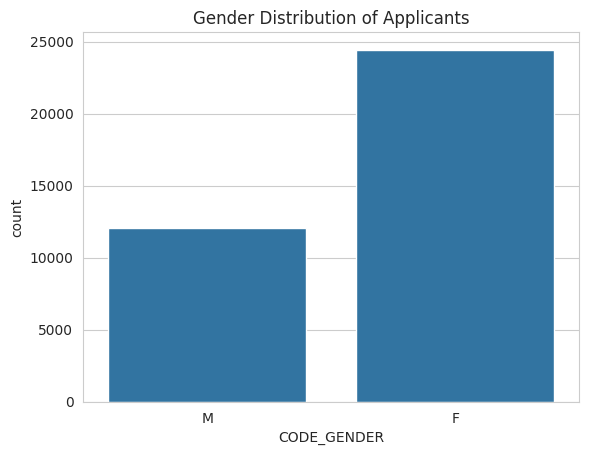

In [32]:
sns.countplot(data=customer_df, x="CODE_GENDER")
plt.title("Gender Distribution of Applicants")
plt.show()

#### B. Income Distribution

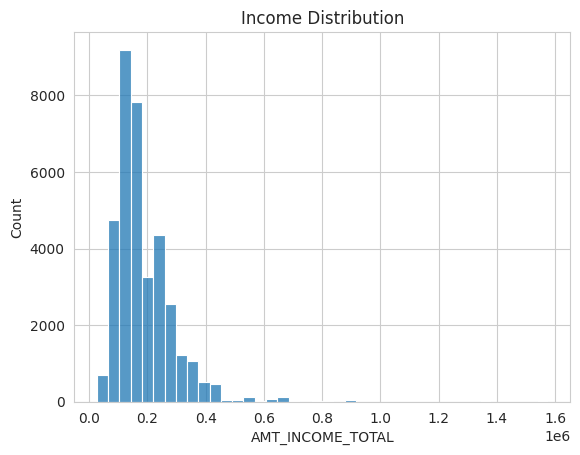

In [33]:
sns.histplot(customer_df['AMT_INCOME_TOTAL'], bins=40)
plt.title("Income Distribution")
plt.show()

## 4.2. Gender Bias Analysis

### A. Income Inequality by gender

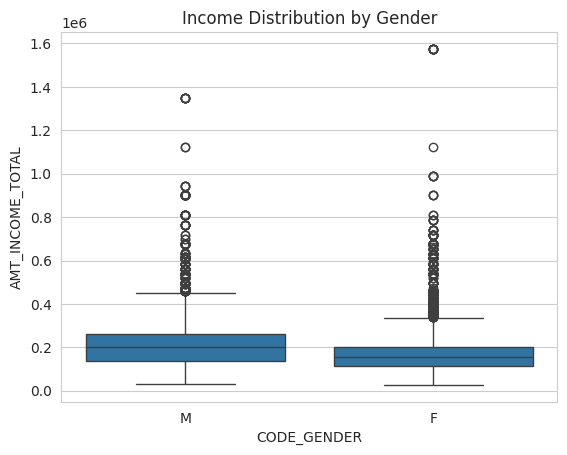

In [34]:
sns.boxplot(
    data=customer_df,
    x="CODE_GENDER",
    y="AMT_INCOME_TOTAL"
)

plt.title("Income Distribution by Gender")
plt.show()

### B. Credit risk by gender

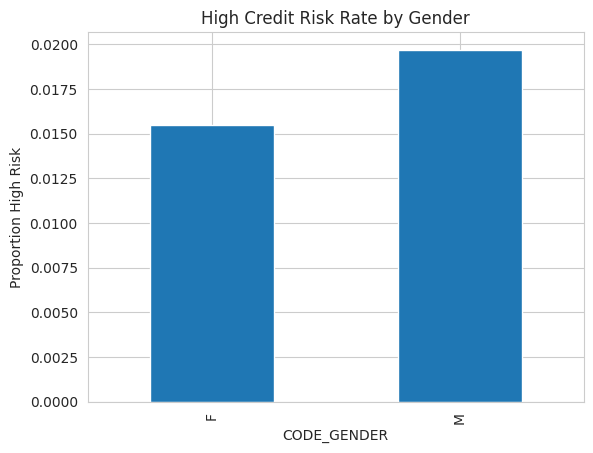

In [35]:
gender_risk = customer_df.groupby("CODE_GENDER")["HIGH_RISK"].mean()

gender_risk.plot(kind="bar")
plt.title("High Credit Risk Rate by Gender")
plt.ylabel("Proportion High Risk")
plt.show()

## 4.3. Education Privilege Analysis

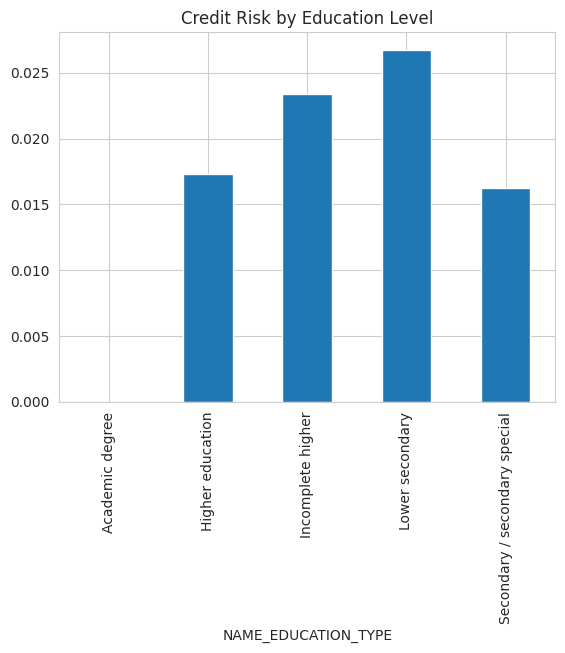

In [36]:
edu_risk = customer_df.groupby("NAME_EDUCATION_TYPE")["HIGH_RISK"].mean()

edu_risk.plot(kind="bar")
plt.title("Credit Risk by Education Level")
plt.show()

## 4.4. Occupation Bias

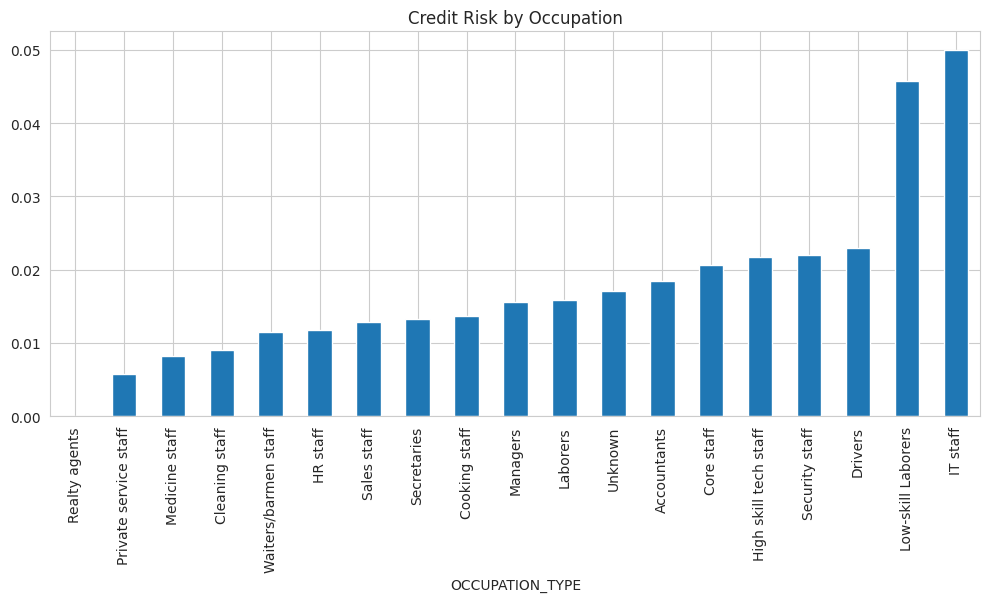

In [37]:
occ_risk = customer_df.groupby("OCCUPATION_TYPE")["HIGH_RISK"].mean().sort_values()

occ_risk.plot(kind="bar", figsize=(12,5))
plt.title("Credit Risk by Occupation")
plt.show()

## 4.5. Housing Bias

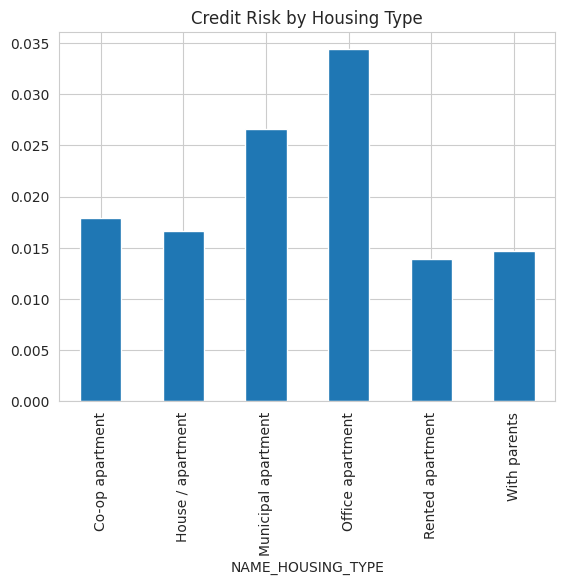

In [38]:
housing_risk = customer_df.groupby("NAME_HOUSING_TYPE")["HIGH_RISK"].mean()

housing_risk.plot(kind="bar")
plt.title("Credit Risk by Housing Type")
plt.show()

## 5. Intersectional Bias

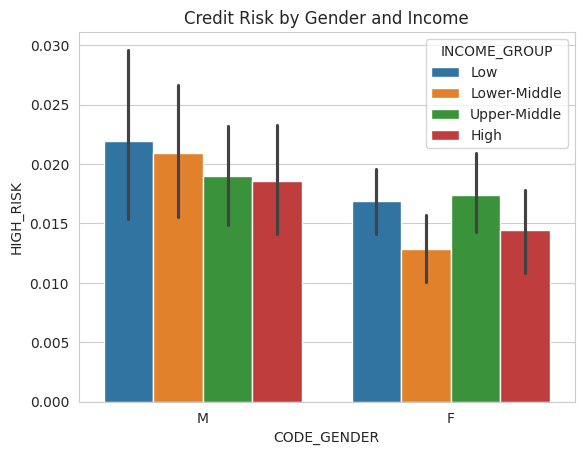

In [39]:
sns.barplot(
    data=customer_df,
    x="CODE_GENDER",
    y="HIGH_RISK",
    hue="INCOME_GROUP"
)

plt.title("Credit Risk by Gender and Income")
plt.show()

## 6. Racial Biases

### 6.1. Generate sysnthetic race data using Probability assumptions (income and occupation correlations)

NOTE: The basis of figures/assumptions used here can change, we need to use reliable source for racial income distribution in south africa

In [42]:
np.random.seed(42)

def assign_race(row):

    # High risk customers
    if row['HIGH_RISK'] == 1:
        return np.random.choice(
            ['Coloured','Black','Indian','White'],
            p=[0.40, 0.35, 0.20, 0.05]
        )

    # Low risk customers
    else:
        return np.random.choice(
            ['White','Indian','Black','Coloured'],
            p=[0.50, 0.25, 0.15, 0.10]
        )

customer_df['RACE'] = customer_df.apply(assign_race, axis=1)

## 7. Race Bias Analysis

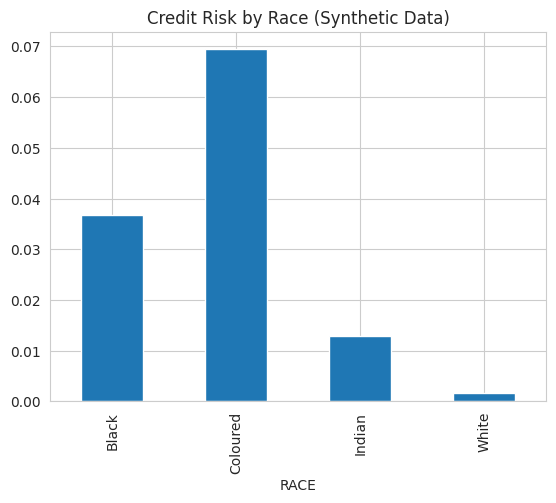

In [43]:
race_risk = customer_df.groupby("RACE")["HIGH_RISK"].mean()

race_risk.plot(kind="bar")
plt.title("Credit Risk by Race (Synthetic Data)")
plt.show()